# Catastrophic Failure Analysis: Globally Finetuned TabPFN

Investigate the 54 counties where finetuned MAPE / zero-shot MAPE > 3.
Goal: identify what these counties share that causes catastrophic failures.

Experiment: `test_v4_geo_k40_ratio80_droplowest5_global_finetuned_internal` (post-fix, Mar 16)

In [1]:
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, "/sailhome/salilg/tabpfn_data_scarcity")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

EXP_DIR     = "/nlp/scr/salilg/property_tax/results/geo_pooling/v2_no_onehot/test_v4_geo_k40_ratio80_droplowest5_global_finetuned_internal_lora_r8"
DATA_PATH   = "/nlp/scr/salilg/property_tax/preprocessed/v2_no_onehot/"
TEST_SET_DIR= "/nlp/scr/salilg/property_tax/preprocessed/v2_no_onehot/test_v4/"
FT_CKPT_DIR = "/nlp/scr/salilg/property_tax/results/global_finetuning/v2_no_onehot/internal_15k/"
TARGET_COL  = "SALE_AMOUNT"
EXCLUDE_COLS = [
    "fips","CLIP","sale_date","Unnamed: 0","ASSESSED_YEAR","CENSUS_ID",
    "PREVIOUS_CLIP","OWNER_TRANSFER_COMPOSITE_TRANSACTION_ID","address",
    "TOTAL_TAX_AMOUNT","NET_TAX_AMOUNT","TAX_RATE_AREA_CODE",
    "CALCULATED_TOTAL_VALUE_SOURCE_CODE","tract","block_group",
    "tract_id","block_group_id","MULTI_OR_SPLIT_PARCEL_CODE","meta_sfh",
    "CALCULATED_TOTAL_VALUE",
]

STATE_FIPS = {
    1:"AL",4:"AZ",5:"AR",6:"CA",8:"CO",9:"CT",10:"DE",12:"FL",13:"GA",
    15:"HI",16:"ID",17:"IL",18:"IN",19:"IA",20:"KS",21:"KY",22:"LA",
    23:"ME",24:"MD",25:"MA",26:"MI",27:"MN",28:"MS",29:"MO",30:"MT",
    31:"NE",32:"NV",33:"NH",34:"NJ",35:"NM",36:"NY",37:"NC",38:"ND",
    39:"OH",40:"OK",41:"OR",42:"PA",44:"RI",45:"SC",46:"SD",47:"TN",
    48:"TX",49:"UT",50:"VT",51:"VA",53:"WA",54:"WV",55:"WI",56:"WY"
}
def to_state(fips): return STATE_FIPS.get(int(str(int(fips)).zfill(5)[:2]), "??")

## 1. Load experiment results and identify catastrophic failures

In [2]:
dfs = []
for chunk in sorted(Path(EXP_DIR).glob("chunk_*/")):
    csv = chunk / "results.csv"
    if csv.exists():
        dfs.append(pd.read_csv(csv))
geo = pd.concat(dfs, ignore_index=True)
geo = geo[geo["status"] == "success"]

piv = geo.pivot_table(index=["fips","own_train_size"], columns="model", values="mape").reset_index()
piv.columns.name = None
piv = piv.dropna(subset=["tabpfn","tabpfn_global_finetuned"])
piv["ratio"] = piv["tabpfn_global_finetuned"] / piv["tabpfn"]
piv["state"] = piv["fips"].apply(to_state)

THRESHOLD = 3.0
catastrophic = piv[piv["ratio"] > THRESHOLD].copy()
normal       = piv[piv["ratio"] <= THRESHOLD].copy()

print(f"Total matched counties: {len(piv)}")
print(f"Catastrophic (ratio>{THRESHOLD}): {len(catastrophic)}")
print(f"Normal (ratio<={THRESHOLD}):      {len(normal)}")
print(f"\nMedian ratio — catastrophic: {catastrophic['ratio'].median():.2f}, normal: {normal['ratio'].median():.2f}")
print(f"Median tabpfn MAPE — catastrophic: {catastrophic['tabpfn'].median():.1f}, normal: {normal['tabpfn'].median():.1f}")
print(f"Median ft MAPE     — catastrophic: {catastrophic['tabpfn_global_finetuned'].median():.1f}, normal: {normal['tabpfn_global_finetuned'].median():.1f}")

Total matched counties: 518
Catastrophic (ratio>3.0): 25
Normal (ratio<=3.0):      493

Median ratio — catastrophic: 4.56, normal: 1.04
Median tabpfn MAPE — catastrophic: 32.9, normal: 37.1
Median ft MAPE     — catastrophic: 149.9, normal: 39.9


## 2. Geographic distribution: which states have the most failures?

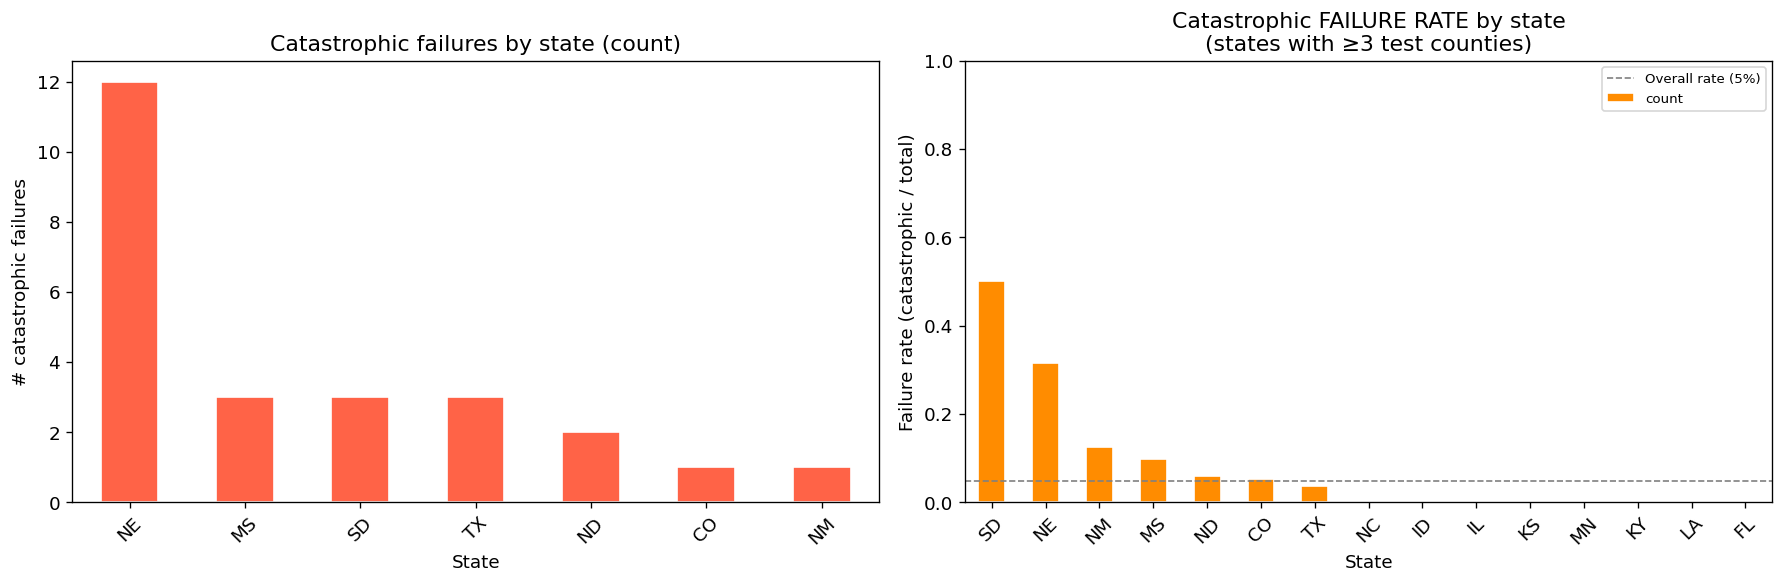


All states — catastrophic count vs total counties vs failure rate:
       n_catastrophic  n_total   rate
state                                
SD                  3        6  0.500
NE                 12       38  0.316
NM                  1        8  0.125
MS                  3       31  0.097
ND                  2       34  0.059
CO                  1       19  0.053
TX                  3       83  0.036
OR                  0        6  0.000
NV                  0        5  0.000
OK                  0       21  0.000
??                  0        9  0.000
SC                  0        3  0.000
UT                  0        5  0.000
VA                  0       16  0.000
WA                  0        4  0.000
WV                  0       26  0.000
TN                  0        3  0.000
NC                  0        3  0.000
AL                  0       14  0.000
MT                  0       15  0.000
MO                  0       27  0.000
MN                  0       12  0.000
LA                  

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: count of catastrophic failures by state
state_counts = catastrophic["state"].value_counts()
all_state_counts = piv["state"].value_counts()
state_rate = (catastrophic["state"].value_counts() / piv["state"].value_counts()).fillna(0).sort_values(ascending=False)

ax = axes[0]
state_counts.head(15).plot(kind="bar", ax=ax, color="tomato", edgecolor="white")
ax.set_xlabel("State"); ax.set_ylabel("# catastrophic failures")
ax.set_title("Catastrophic failures by state (count)")
ax.tick_params(axis="x", rotation=45)

# Right: failure RATE per state (only states with >=3 counties in test set)
ax = axes[1]
min_counties = 3
eligible = all_state_counts[all_state_counts >= min_counties].index
rate_eligible = state_rate[state_rate.index.isin(eligible)].sort_values(ascending=False).head(15)
rate_eligible.plot(kind="bar", ax=ax, color="darkorange", edgecolor="white")
ax.set_xlabel("State"); ax.set_ylabel("Failure rate (catastrophic / total)")
ax.set_title(f"Catastrophic FAILURE RATE by state\n(states with ≥{min_counties} test counties)")
ax.set_ylim(0, 1)
ax.axhline(len(catastrophic)/len(piv), color="gray", ls="--", lw=1, label=f"Overall rate ({len(catastrophic)/len(piv)*100:.0f}%)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("\nAll states — catastrophic count vs total counties vs failure rate:")
summary = pd.DataFrame({"n_catastrophic": state_counts, "n_total": all_state_counts}).fillna(0).astype(int)
summary["rate"] = (summary["n_catastrophic"] / summary["n_total"]).round(3)
print(summary[summary["n_total"] >= 3].sort_values("rate", ascending=False).to_string())

## 3. Property distributions: catastrophic vs normal counties

Are catastrophic counties systematically different in own_train_size, n_cont, y scale, etc.?

In [4]:
from src.data.split_strategies import load_test_set_result
from src.data.loading import CleanedDataLoader

print("Loading test split and data...")
test_result = load_test_set_result(TEST_SET_DIR)
loader = CleanedDataLoader(cleaned_data_path=DATA_PATH, target_column=TARGET_COL)
all_indices = np.unique(np.concatenate([test_result.test_indices, test_result.train_pool_indices]))
df = loader.load_data_by_indices(all_indices)

index_map = {old: new for new, old in enumerate(all_indices)}
fips_col = df["fips"].values
float_cols = [c for c in df.columns if c not in set(EXCLUDE_COLS + [TARGET_COL])
              and pd.api.types.is_float_dtype(df[c])]

# Per-county stats
records = []
for fips in test_result.test_counties:
    fips_int = int(fips)
    remapped_train = np.array([index_map[i] for i in test_result.train_pool_indices if i in index_map])
    train_mask = fips_col[remapped_train] == fips_int
    county_train_idx = remapped_train[train_mask]
    if len(county_train_idx) == 0:
        continue
    X_own = df.iloc[county_train_idx]
    y_own = np.log(X_own[TARGET_COL].dropna().values)
    n_cont = int((~df.iloc[county_train_idx][float_cols].isnull().all(axis=0)).sum())
    records.append({
        "fips": fips_int,
        "own_train_size": len(county_train_idx),
        "n_cont": n_cont,
        "y_mean": float(y_own.mean()) if len(y_own) > 0 else np.nan,
        "y_std":  float(y_own.std())  if len(y_own) > 1 else np.nan,
    })

fips_stats = pd.DataFrame(records)
print(f"Computed stats for {len(fips_stats)} counties")

Loading test split and data...
Computed stats for 525 counties


/nlp/scr/salilg/miniconda3/envs/tabpfn_env/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/nlp/scr/salilg/miniconda3/envs/tabpfn_env/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


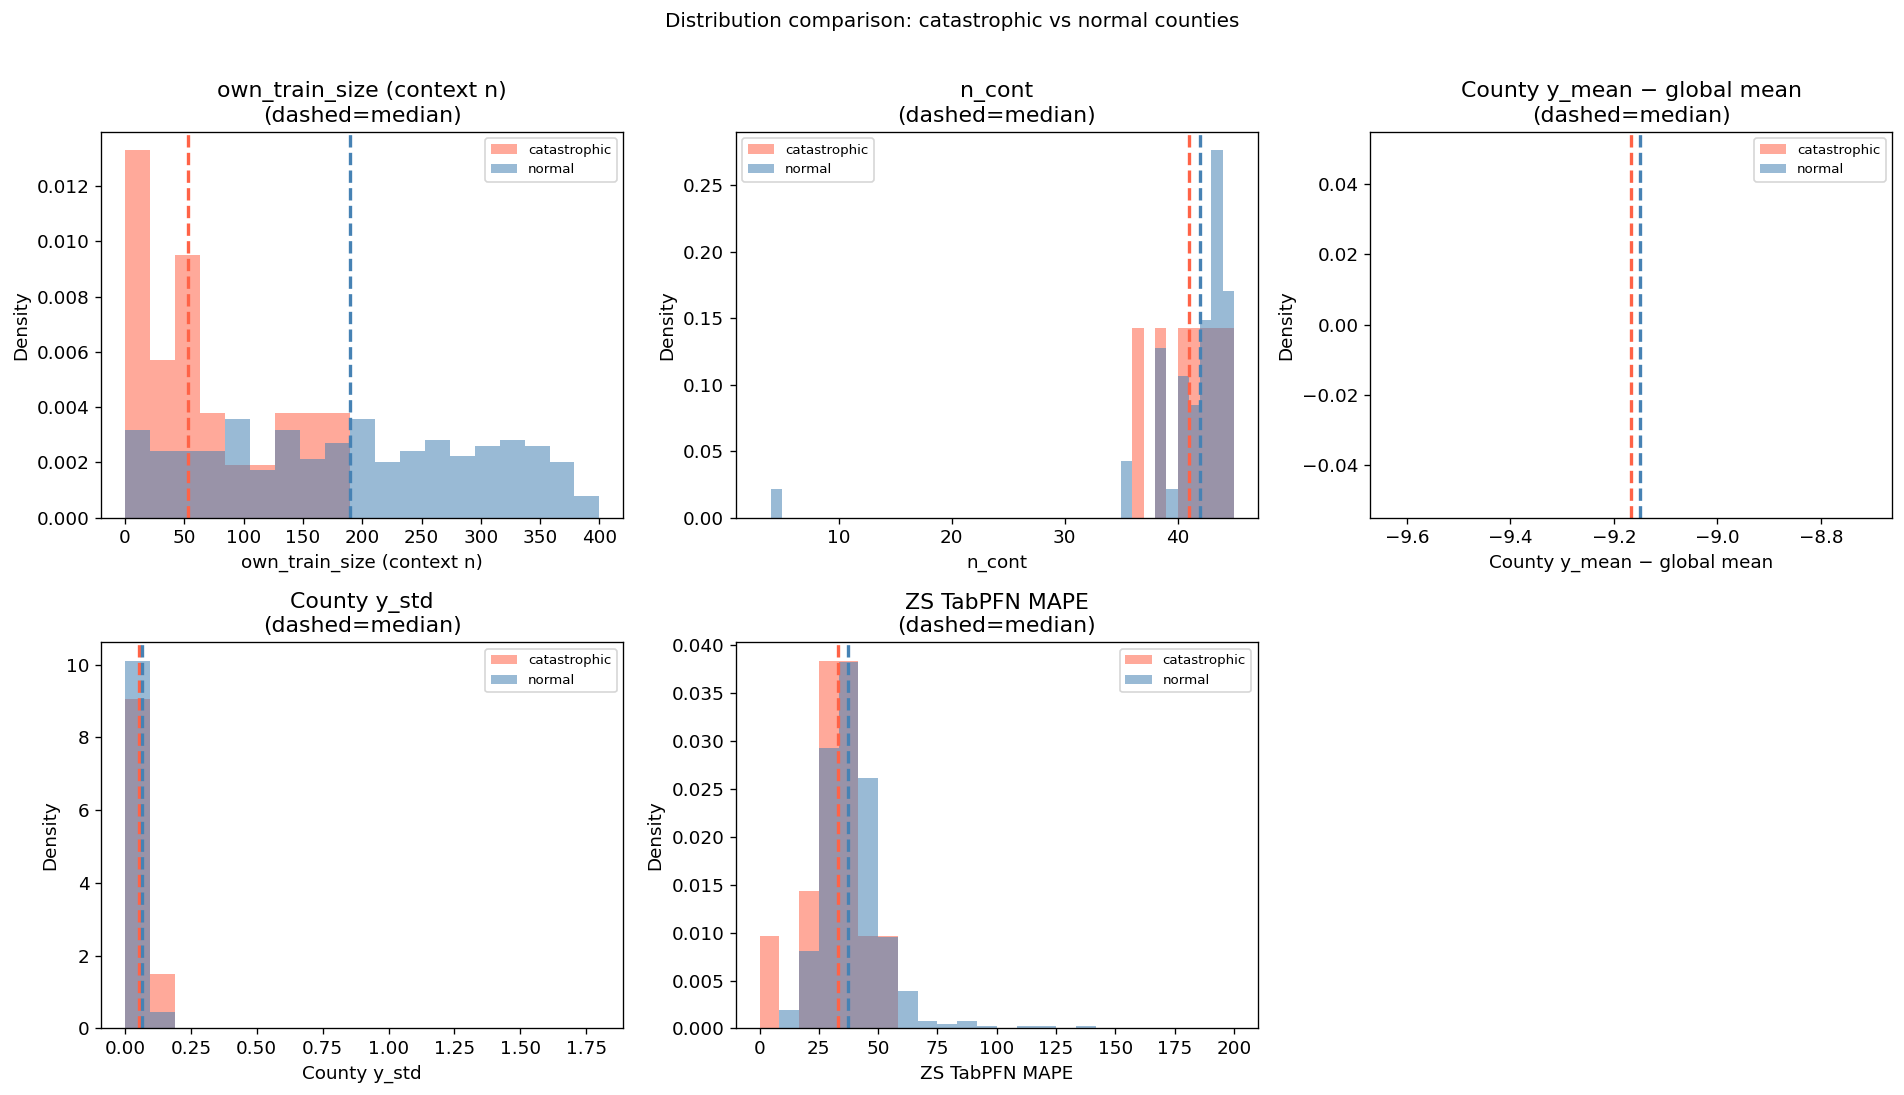


Median values — catastrophic vs normal:
  own_train_size        catastrophic=53.000  normal=190.000
  n_cont                catastrophic=41.000  normal=42.000
  y_offset              catastrophic=-9.166  normal=-9.150
  y_std                 catastrophic=0.054  normal=0.065
  tabpfn                catastrophic=32.875  normal=37.098


In [5]:
# Merge with catastrophic/normal labels
GLOBAL_Y_MEAN = 11.5913
piv_stats = piv.merge(fips_stats, on=["fips","own_train_size"], how="left")
piv_stats["y_offset"] = piv_stats["y_mean"] - GLOBAL_Y_MEAN
piv_stats["group"] = np.where(piv_stats["ratio"] > THRESHOLD, "catastrophic", "normal")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
props = [
    ("own_train_size", "own_train_size (context n)", True),
    ("n_cont",         "n_cont",                     False),
    ("y_offset",       "County y_mean − global mean",False),
    ("y_std",          "County y_std",                False),
    ("tabpfn",         "ZS TabPFN MAPE",              False),
]
bins_map = {
    "own_train_size": np.linspace(0,400,20),
    "n_cont": np.arange(3,46),
    "y_offset": np.linspace(-2,2,25),
    "y_std": np.linspace(0,1.8,20),
    "tabpfn": np.linspace(0,200,25),
}

for i, (col, label, log_x) in enumerate(props):
    ax = axes.flat[i]
    for grp, color in [("catastrophic","tomato"),("normal","steelblue")]:
        vals = piv_stats[piv_stats["group"]==grp][col].dropna()
        b = bins_map.get(col, 20)
        ax.hist(vals, bins=b, density=True, alpha=0.55, color=color, label=grp, edgecolor="none")
        ax.axvline(vals.median(), color=color, lw=2, ls="--")
    ax.set_xlabel(label); ax.set_ylabel("Density")
    ax.set_title(f"{label}\n(dashed=median)")
    ax.legend(fontsize=8)

axes.flat[-1].set_visible(False)
plt.suptitle("Distribution comparison: catastrophic vs normal counties", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Numerical summary
print("\nMedian values — catastrophic vs normal:")
for col in ["own_train_size","n_cont","y_offset","y_std","tabpfn"]:
    c_med = piv_stats[piv_stats["group"]=="catastrophic"][col].median()
    n_med = piv_stats[piv_stats["group"]=="normal"][col].median()
    print(f"  {col:20s}  catastrophic={c_med:.3f}  normal={n_med:.3f}")

## 4. Are catastrophic counties in the finetuning training set?

If so, the model may have memorized them or been exposed to very different versions of them.

In [6]:
# Load finetuning metadata to find what counties were used for training
ft_metadata = json.load(open(FT_CKPT_DIR + "metadata.json"))
ft_results_csv = FT_CKPT_DIR + "results.csv"
if Path(ft_results_csv).exists():
    ft_results = pd.read_csv(ft_results_csv)
    print("Finetuning results.csv columns:", ft_results.columns.tolist())
    print(ft_results.head())

# The finetuning training data: load split info
# The "internal" split means counties NOT in the test set
test_fips_set = set(int(f) for f in test_result.test_counties)
ft_train_fips = set(int(f) for f in fips_col if f not in test_fips_set)  # rough approximation

cat_fips = set(catastrophic["fips"].astype(int))
overlap_with_test = cat_fips & test_fips_set
overlap_with_ft_train = cat_fips - test_fips_set

print(f"\nCatastrophic county FIPS: {sorted(cat_fips)[:10]}...")
print(f"Are catastrophic counties in test set? {len(cat_fips & test_fips_set)}/{len(cat_fips)}")
print(f"(All geo-pooling counties should be test counties)")
print(f"\nNote: finetuning used 'internal' data = counties NOT in external test set.")
print(f"Check if catastrophic counties' FIPS prefixes cluster in specific regions.")
print(f"\nState breakdown of catastrophic failures:")
cat_states = catastrophic["state"].value_counts()
total_by_state = piv["state"].value_counts()
for state in cat_states.index:
    n_cat = cat_states[state]
    n_tot = total_by_state.get(state, 0)
    print(f"  {state}: {n_cat}/{n_tot} ({100*n_cat/n_tot:.0f}%) catastrophic")

Finetuning results.csv columns: ['experiment_name', 'variant', 'n_samples', 'n_features', 'best_epoch', 'best_val_loss', 'n_epochs_trained', 'total_time_seconds', 'checkpoint_dir', 'status', 'experiment_description']
          experiment_name   variant  n_samples  n_features  best_epoch  \
0  global_ft_internal_15k  internal      14254         107           8   

   best_val_loss  n_epochs_trained  total_time_seconds  \
0      -0.425957                24         1518.859362   

                                      checkpoint_dir   status  \
0  /scratch/users/salilg/property_tax/results/glo...  success   

                              experiment_description  
0  Global TabPFN finetuning on 15K samples from t...  

Catastrophic county FIPS: [8033, 28021, 28037, 28039, 31007, 31015, 31017, 31049, 31057, 31063]...
Are catastrophic counties in test set? 25/25
(All geo-pooling counties should be test counties)

Note: finetuning used 'internal' data = counties NOT in external test set.
Chec

## 5. What do predictions look like for catastrophic counties?

Plot predictions vs y_true for a few catastrophic counties to see the failure mode.

Showcasing FIPS: [31117, 35021, 8033, 48137, 31149, 31063]


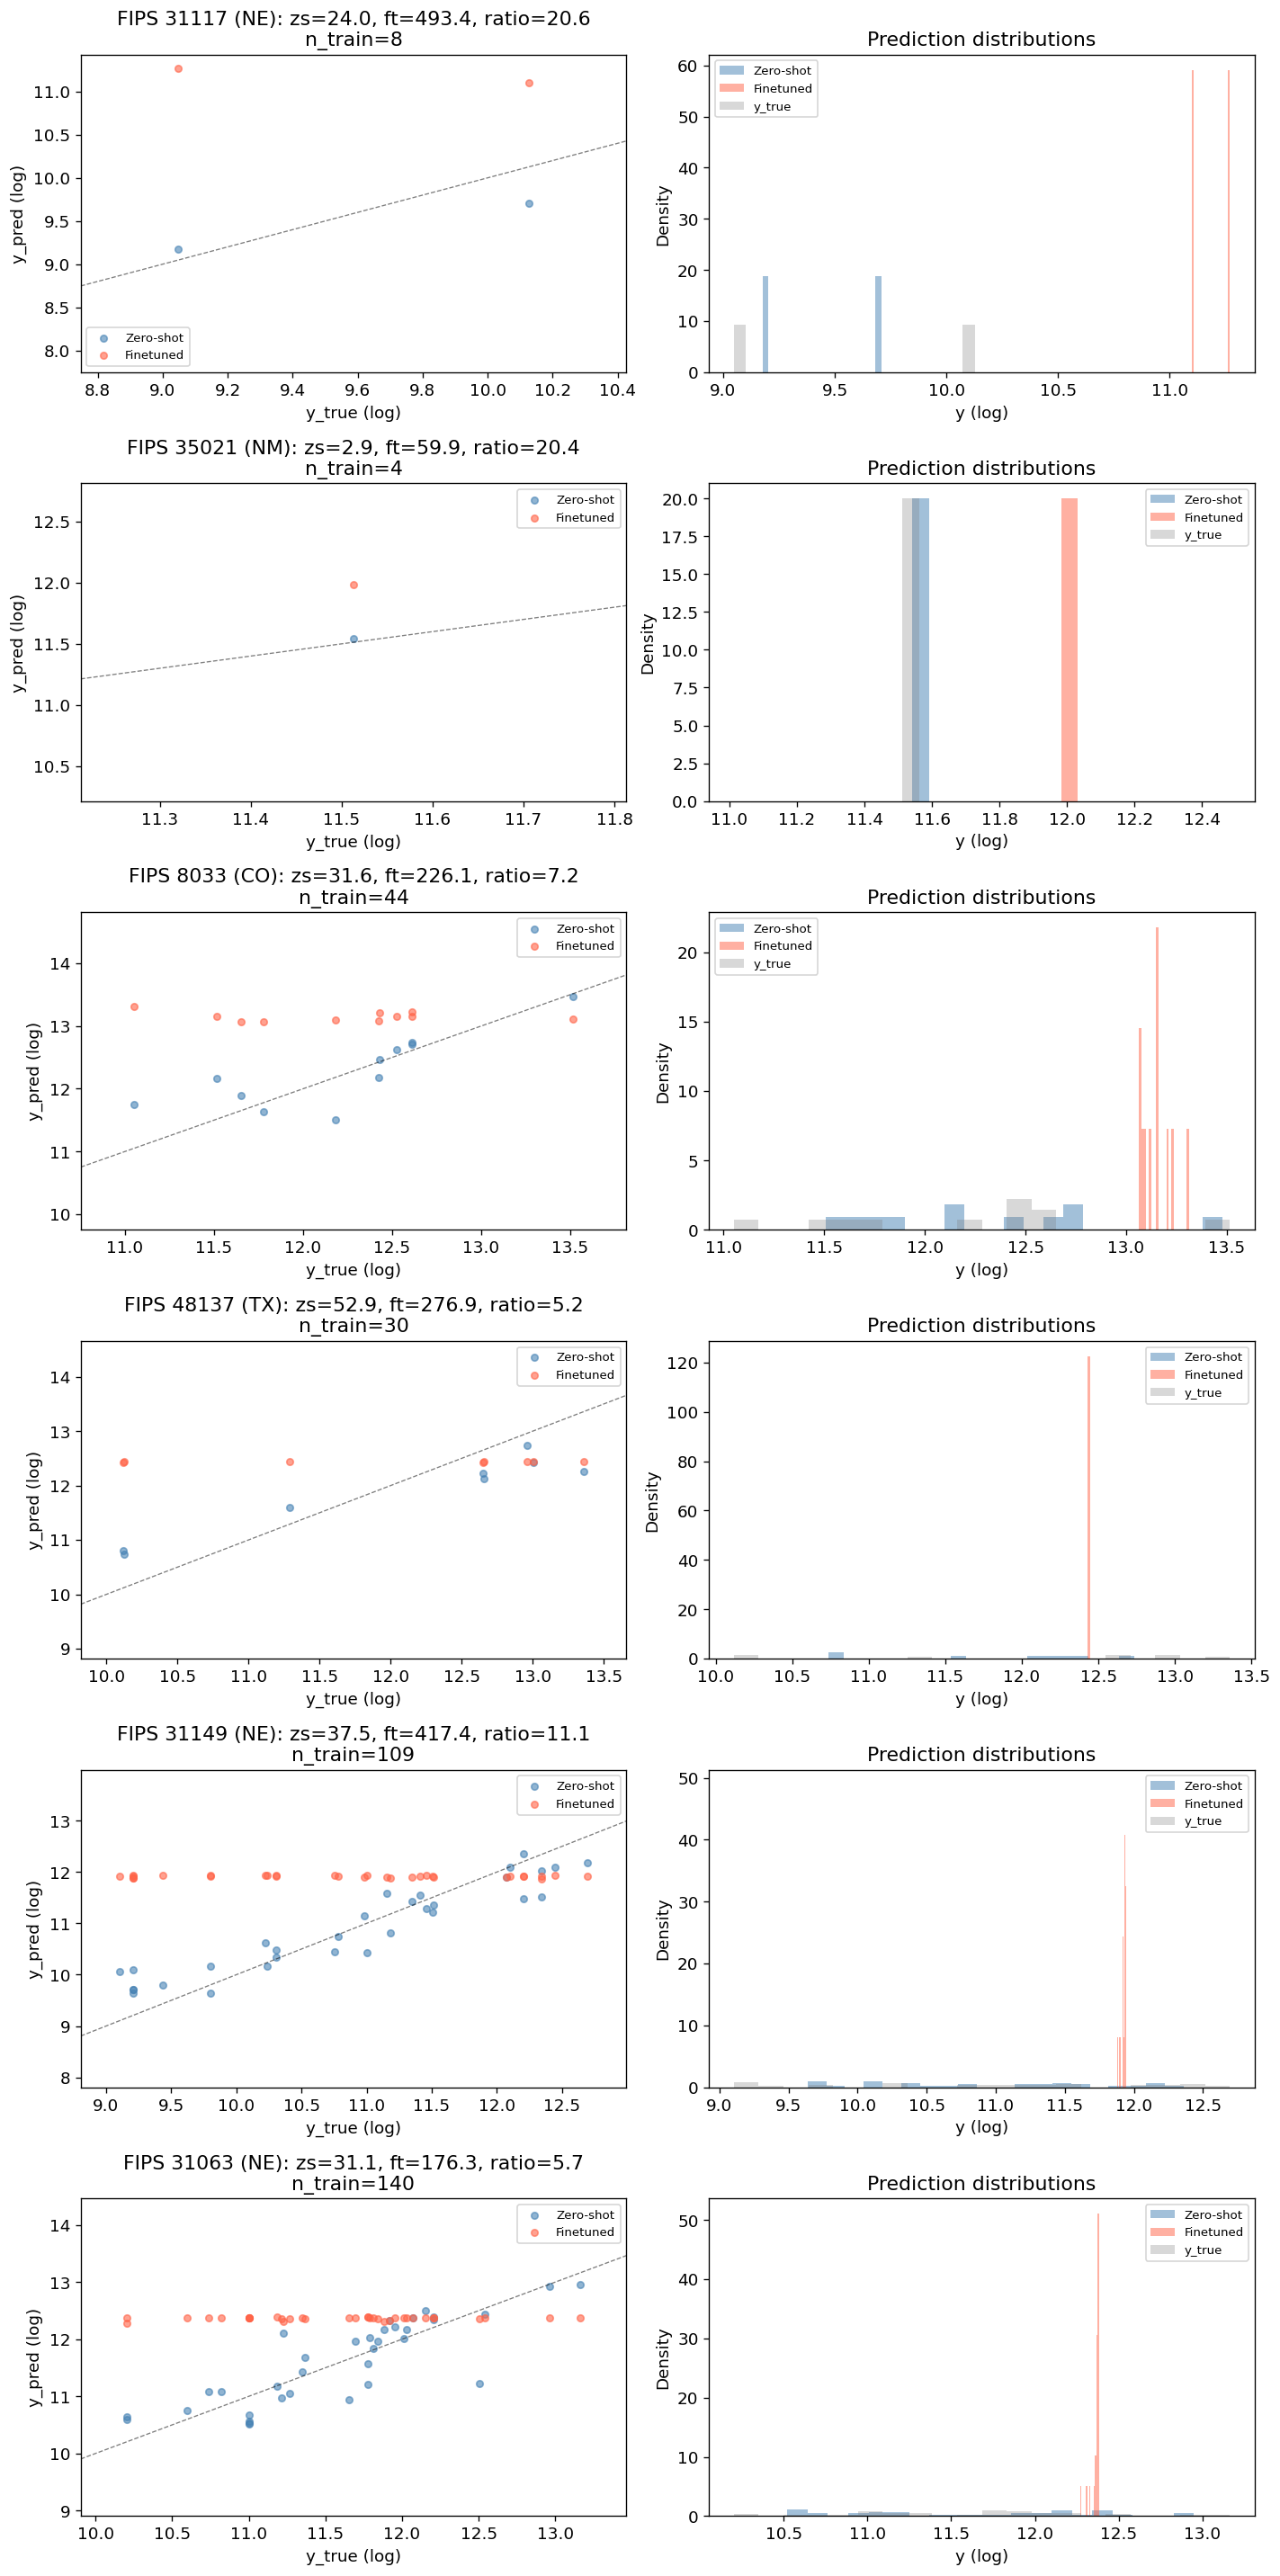

In [7]:
# Load per-sample predictions
pred_dfs = []
for chunk in sorted(Path(EXP_DIR).glob("chunk_*/")):
    pred_path = chunk / "predictions.parquet"
    if pred_path.exists():
        pred_dfs.append(pd.read_parquet(pred_path, columns=["fips","model","y_true","y_pred"]))
preds = pd.concat(pred_dfs, ignore_index=True)

# Pick 6 catastrophic counties to visualize — mix of small and large sizes
cat_sorted = catastrophic.sort_values("ratio", ascending=False)
showcase_fips = cat_sorted["fips"].astype(int).head(6).tolist()
# Try to include mix of sizes
small = cat_sorted[cat_sorted["own_train_size"] < 30]["fips"].astype(int).head(2).tolist()
large = cat_sorted[cat_sorted["own_train_size"] >= 100]["fips"].astype(int).head(2).tolist()
medium = cat_sorted[(cat_sorted["own_train_size"] >= 30) & (cat_sorted["own_train_size"] < 100)]["fips"].astype(int).head(2).tolist()
showcase_fips = list(dict.fromkeys(small + medium + large))[:6]
print(f"Showcasing FIPS: {showcase_fips}")

fig, axes = plt.subplots(len(showcase_fips), 2, figsize=(12, 4 * len(showcase_fips)))
if len(showcase_fips) == 1:
    axes = axes.reshape(1, -1)

for i, fips_i in enumerate(showcase_fips):
    county_preds = preds[preds["fips"] == fips_i]
    row = cat_sorted[cat_sorted["fips"] == fips_i].iloc[0]
    
    for model, color, label in [("tabpfn","steelblue","Zero-shot"), ("tabpfn_global_finetuned","tomato","Finetuned")]:
        mp = county_preds[county_preds["model"] == model]
        
        # Scatter
        ax = axes[i, 0]
        ax.scatter(mp["y_true"], mp["y_pred"], alpha=0.6, s=20, color=color, label=label)
    
    # y=x line
    ax = axes[i, 0]
    lo = county_preds["y_true"].min() - 0.3
    hi = county_preds["y_true"].max() + 0.3
    ax.plot([lo,hi],[lo,hi],'k--',lw=0.8,alpha=0.5)
    ax.set_xlim(lo,hi); ax.set_ylim(lo-1, hi+1)
    ax.set_xlabel("y_true (log)"); ax.set_ylabel("y_pred (log)")
    state = to_state(fips_i)
    ax.set_title(f"FIPS {fips_i} ({state}): zs={row['tabpfn']:.1f}, ft={row['tabpfn_global_finetuned']:.1f}, ratio={row['ratio']:.1f}\nn_train={int(row['own_train_size'])}")
    ax.legend(fontsize=8)
    
    # Histogram of predictions
    ax = axes[i, 1]
    for model, color, label in [("tabpfn","steelblue","Zero-shot"), ("tabpfn_global_finetuned","tomato","Finetuned")]:
        mp = county_preds[county_preds["model"] == model]
        ax.hist(mp["y_pred"], bins=20, alpha=0.5, color=color, label=label, density=True)
    ax.hist(county_preds[county_preds["model"]=="tabpfn"]["y_true"], bins=20, 
            alpha=0.3, color="gray", label="y_true", density=True)
    ax.set_xlabel("y (log)"); ax.set_ylabel("Density")
    ax.set_title("Prediction distributions")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
catastrophic

,fips,own_train_size,tabpfn,tabpfn_global_finetuned,xgboost,ratio,state
39,8033,44,31.598448,226.051737,33.099463,7.153887,CO
178,28021,9,25.638908,97.384813,15.609287,3.798321,MS
181,28037,8,28.444180,195.734059,69.703510,6.881340,MS
182,28039,5,3.729557,43.955580,21.373333,11.785737,MS
249,31007,5,17.710923,83.742056,49.696477,4.728272,NE
251,31015,62,42.283981,160.975946,38.344060,3.807020,NE
252,31017,133,25.924476,83.969220,26.793703,3.238994,NE
256,31049,184,37.649699,120.433426,42.038193,3.198789,NE
257,31057,177,41.567096,148.885783,37.081593,3.581818,NE
259,31063,140,31.103960,176.339435,26.383139,5.669356,NE


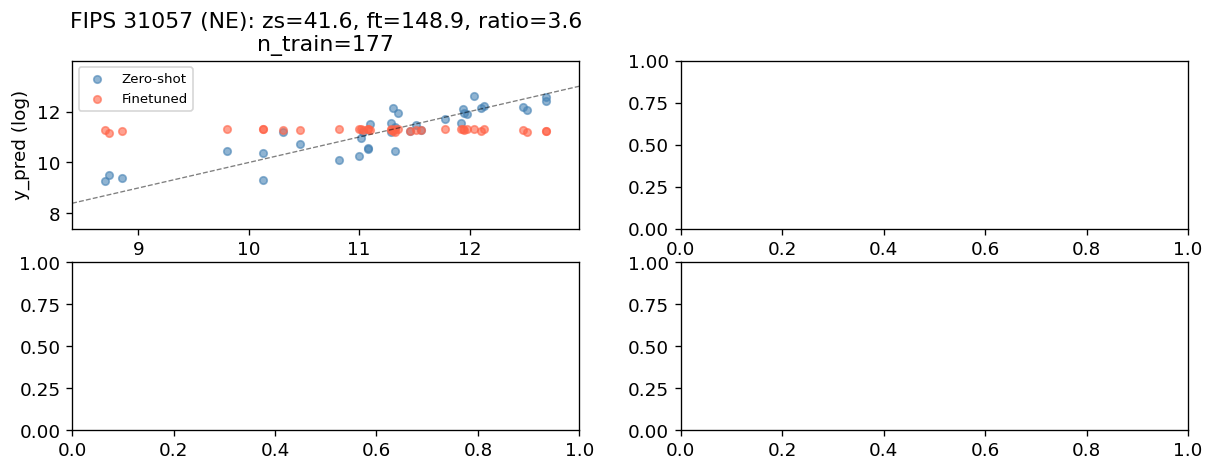

In [14]:
i, fips_i = 0, 31057

county_preds = preds[preds["fips"] == fips_i]
row = cat_sorted[cat_sorted["fips"] == fips_i].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 4))

for model, color, label in [("tabpfn","steelblue","Zero-shot"), ("tabpfn_global_finetuned","tomato","Finetuned")]:
    mp = county_preds[county_preds["model"] == model]
    
    # Scatter
    ax = axes[i, 0]
    ax.scatter(mp["y_true"], mp["y_pred"], alpha=0.6, s=20, color=color, label=label)

# y=x line
ax = axes[i, 0]
lo = county_preds["y_true"].min() - 0.3
hi = county_preds["y_true"].max() + 0.3
ax.plot([lo,hi],[lo,hi],'k--',lw=0.8,alpha=0.5)
ax.set_xlim(lo,hi); ax.set_ylim(lo-1, hi+1)
ax.set_xlabel("y_true (log)"); ax.set_ylabel("y_pred (log)")
state = to_state(fips_i)
ax.set_title(f"FIPS {fips_i} ({state}): zs={row['tabpfn']:.1f}, ft={row['tabpfn_global_finetuned']:.1f}, ratio={row['ratio']:.1f}\nn_train={int(row['own_train_size'])}")
ax.legend(fontsize=8)

## 6. Feature distribution for catastrophic counties vs training data

Are catastrophic counties' features out-of-distribution relative to the finetuning training data?

Top 15 features most different between catastrophic and normal counties:
census_pct_senior_tract         0.517
census_med_yr_built_bg          0.485
census_med_yr_built_tract       0.417
census_pct_snap_tract           0.415
census_pct_senior_bg            0.403
census_pct_renter_occ_tract     0.381
char_land_sf                    0.371
census_pct_college_bg           0.371
census_pct_college_tract        0.343
char_beds                       0.341
census_med_age_tract            0.322
census_med_per_cap_inc_tract    0.287
ASSESSED_TOTAL_VALUE            0.282
char_stories                    0.281
char_gar1_sf                    0.276


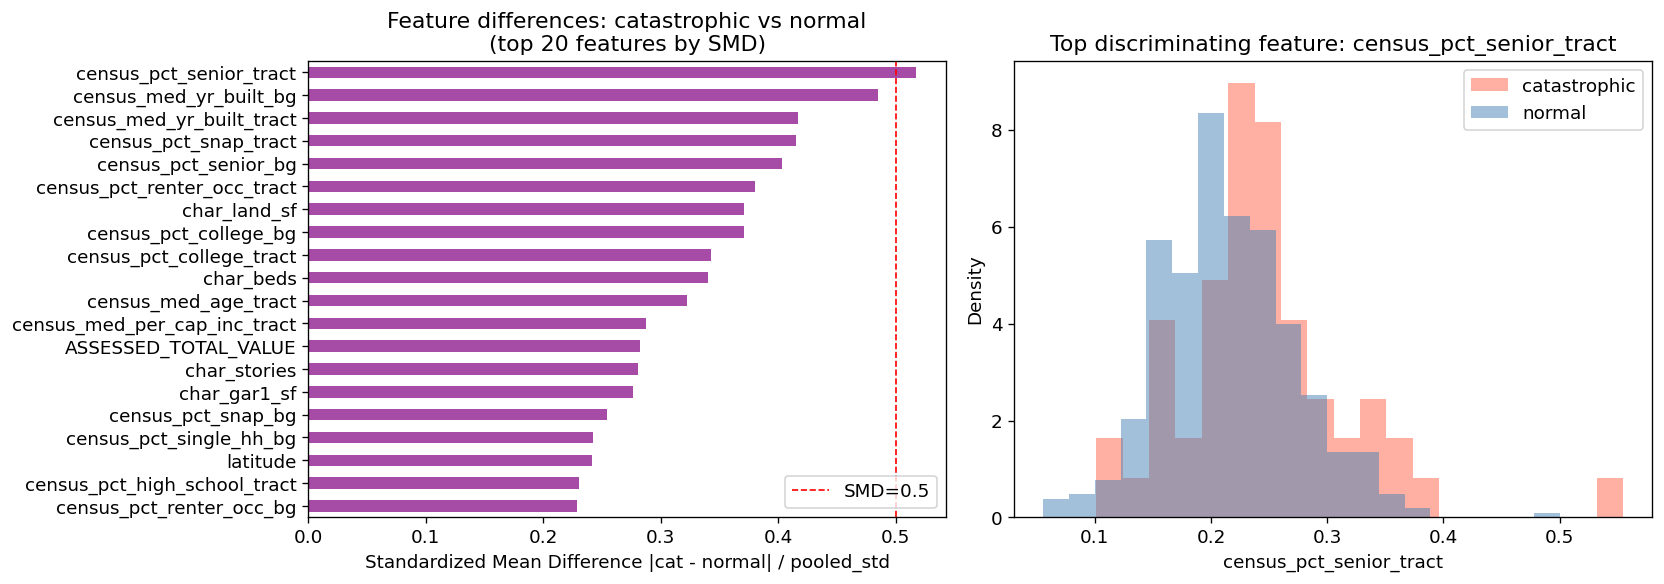

In [8]:
# Load finetuning training data to compare feature distributions
# The finetuning used 'internal' data — non-test counties
# Approximate by comparing catastrophic test counties vs all non-test counties

# For each catastrophic county, compute mean feature vector
# Compare to mean feature vector of non-catastrophic and non-test counties

from src.data.loading import CleanedDataLoader

loader = CleanedDataLoader(cleaned_data_path=DATA_PATH, target_column=TARGET_COL)
drop_cols = set(EXCLUDE_COLS + [TARGET_COL])
feature_cols = [c for c in df.columns if c not in drop_cols]
float_cols_feat = [c for c in feature_cols if pd.api.types.is_float_dtype(df[c])]

remapped_train_pool = np.array([index_map[i] for i in test_result.train_pool_indices if i in index_map])

cat_fips_set = set(catastrophic["fips"].astype(int).tolist())
normal_fips_set = set(normal["fips"].astype(int).tolist())

def get_county_features(fips_int, df, remapped_train_pool, fips_col, float_cols_feat):
    mask = fips_col[remapped_train_pool] == fips_int
    idx = remapped_train_pool[mask]
    if len(idx) == 0:
        return None
    return df.iloc[idx][float_cols_feat].median()

cat_feat = pd.DataFrame([get_county_features(f, df, remapped_train_pool, fips_col, float_cols_feat) 
                          for f in cat_fips_set if get_county_features(f, df, remapped_train_pool, fips_col, float_cols_feat) is not None])
norm_feat = pd.DataFrame([get_county_features(f, df, remapped_train_pool, fips_col, float_cols_feat) 
                           for f in normal_fips_set if get_county_features(f, df, remapped_train_pool, fips_col, float_cols_feat) is not None])

# Compute standardized mean difference per feature
cat_mean = cat_feat.mean()
norm_mean = norm_feat.mean()
pooled_std = pd.concat([cat_feat, norm_feat]).std().replace(0, np.nan)
smd = ((cat_mean - norm_mean) / pooled_std).dropna().abs().sort_values(ascending=False)

print(f"Top 15 features most different between catastrophic and normal counties:")
print(smd.head(15).round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
smd.head(20).sort_values().plot(kind="barh", ax=ax, color="purple", alpha=0.7)
ax.set_xlabel("Standardized Mean Difference |cat - normal| / pooled_std")
ax.set_title("Feature differences: catastrophic vs normal\n(top 20 features by SMD)")
ax.axvline(0.5, color="red", ls="--", lw=1, label="SMD=0.5")
ax.legend()

# For top discriminating feature, show distributions
top_feat = smd.index[0]
ax = axes[1]
ax.hist(cat_feat[top_feat].dropna(), bins=20, alpha=0.5, color="tomato", density=True, label="catastrophic")
ax.hist(norm_feat[top_feat].dropna(), bins=20, alpha=0.5, color="steelblue", density=True, label="normal")
ax.set_xlabel(top_feat); ax.set_ylabel("Density")
ax.set_title(f"Top discriminating feature: {top_feat}")
ax.legend()

plt.tight_layout()
plt.show()